In [1]:
#부동산 투자 예측 모델 구현 - 모델 구현 및 평가
# AI테크노융합학과
# 유영재, 윤지환

from google.colab import drive
drive.mount('/content/drive')
import unicodedata
import os

# Define the path to the folder in Google Drive
folder_path = '/content/drive/My Drive/estate'

# List files in the folder
files = os.listdir(folder_path)

import pandas as pd
import os


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:

# Load the dataframes
df = pd.read_csv(os.path.join(folder_path, 'merged_with_school.csv'))

# Normalize column names to remove whitespace
df.columns = [col.strip() for col in df.columns]

# Debug: Print columns and dtypes
print("all columns:", df.columns.tolist())

all columns: ['접수연도', '자치구코드', '자치구명', '법정동코드', '법정동명', '건물명', '계약일', '물건금액(만원)', '건물면적(㎡)', '토지면적(㎡)', '층', '건축년도', '역개수', '학교수']


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import joblib
import matplotlib.pyplot as plt

# 2. 전처리
df = df[df['건물면적(㎡)'] > 0]
df['평단가'] = df['물건금액(만원)'] / df['건물면적(㎡)']

# 필요 피처 선택 (예시)
features = ['역개수', '학교수', '건물면적(㎡)', '토지면적(㎡)', '건축년도']
X = df[features]
y = df['평단가']

# 정규화
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. 모델 학습
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. 성능 평가
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n📈 개선된 모델 평가 결과")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

# 5. 모델 저장
joblib.dump(model, 'real_estate_price_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')



📈 개선된 모델 평가 결과
Mean Squared Error: 55851.33
R² Score: 0.9059


['feature_scaler.pkl']

✅ 현재 사용 중인 폰트: NanumGothic


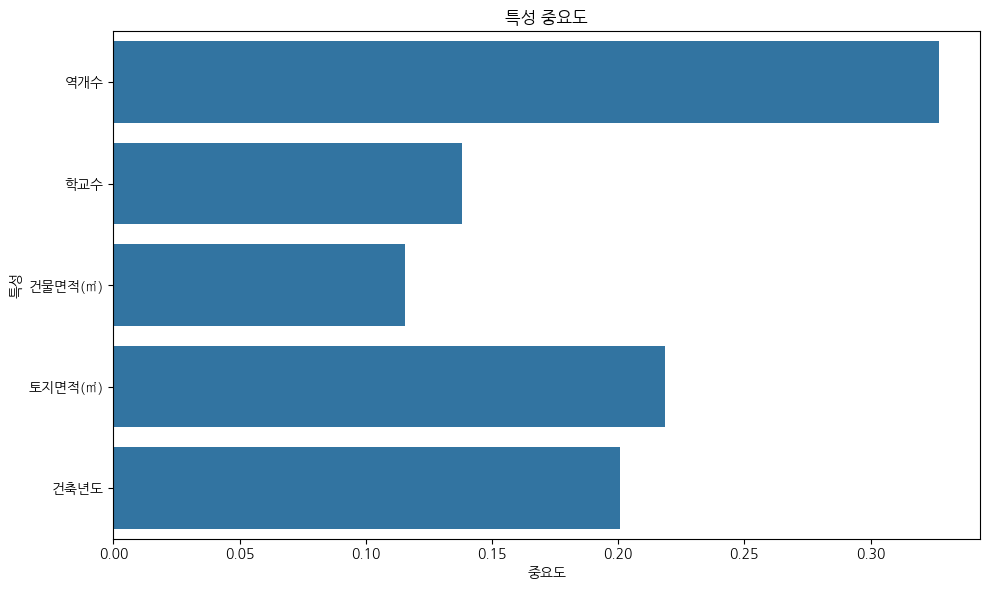

In [4]:

# 1. 필요한 라이브러리 임포트
import matplotlib.pyplot as plt
import matplotlib       # 이 라인 추가
from matplotlib import font_manager, rc
import seaborn as sns
import platform
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns

# 설치
!apt-get -y install fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1
!rm -rf ~/.cache/matplotlib

# 설정
import matplotlib.pyplot as plt
from matplotlib import font_manager
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False
print(f"✅ 현재 사용 중인 폰트: {font_name}")

# 4. 특성 중요도 시각화 예시
feature_importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=features)
plt.title("특성 중요도")
plt.xlabel("중요도")
plt.ylabel("특성")
plt.tight_layout()
plt.show()

In [5]:

# 예측 수행
y_pred = model.predict(X_test)

# 평가 지표 계산
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# MAPE 계산 (0인 경우 방지 위해 작은 epsilon 추가)
epsilon = 1e-10
mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100

# 결과 출력
print("📊 모델 평가 지표")
print("---------------------------------------")
print(f"🔹 MAE (평균 절댓값 오차): {mae:.2f} 만원/㎡")
print(f"🔹 MSE (평균 제곱 오차): {mse:.2f}")
print(f"🔹 RMSE (제곱근 평균 제곱 오차): {rmse:.2f} 만원/㎡")
print(f"🔹 MAPE (평균 절대 백분율 오차): {mape:.2f}%")
print(f"🔹 R² Score: {r2:.4f}")
print("---------------------------------------")

📊 모델 평가 지표
---------------------------------------
🔹 MAE (평균 절댓값 오차): 113.74 만원/㎡
🔹 MSE (평균 제곱 오차): 55851.33
🔹 RMSE (제곱근 평균 제곱 오차): 236.33 만원/㎡
🔹 MAPE (평균 절대 백분율 오차): 11.76%
🔹 R² Score: 0.9059
---------------------------------------


<ipython-input-6-3332291153>:23: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


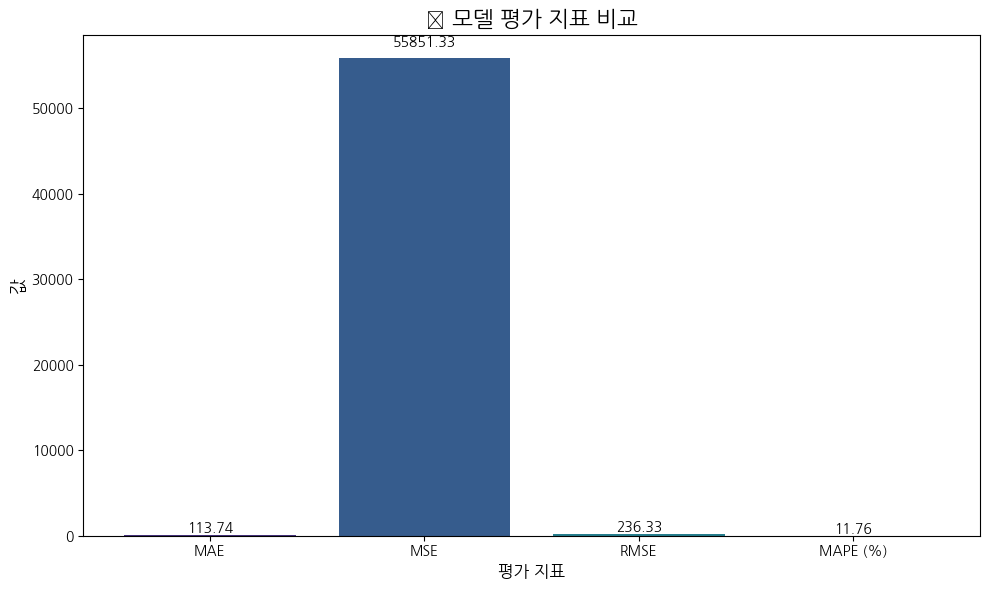

In [6]:
# 이전에 계산한 지표들
metrics = {
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'MAPE (%)': mape
}

r2 = r2  # R² 점수

# 📊 1. MAE, MSE, RMSE, MAPE 비교 차트
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics.keys(), metrics.values(), color=sns.color_palette("viridis"))
plt.title('📊 모델 평가 지표 비교', fontsize=16)
plt.ylabel('값', fontsize=12)
plt.xlabel('평가 지표', fontsize=12)

# 값 표시
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02*yval, f"{yval:.2f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


<ipython-input-7-4265638508>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['R²'], y=[r2], palette="Blues_d")
<ipython-input-7-4265638508>:9: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


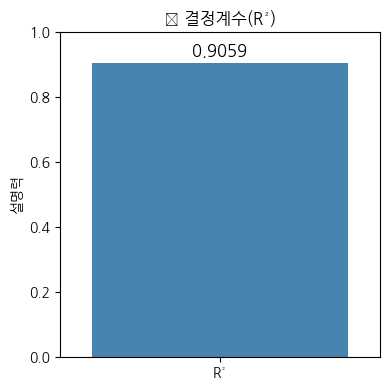

In [7]:

# 📊 2. R² Score 별도 차트
plt.figure(figsize=(4, 4))
sns.barplot(x=['R²'], y=[r2], palette="Blues_d")
plt.ylim(0, 1)
plt.title('🔹 결정계수(R²)')
plt.text(0, r2 + 0.02, f"{r2:.4f}", ha='center', fontsize=12)
plt.ylabel('설명력', fontsize=10)
plt.xlabel('')
plt.tight_layout()
plt.show()

In [8]:

# 6. 사용자 입력 기반 예측
while True:
    user_input = input("\n🔍 예측하고 싶은 자치구명을 입력하세요 (종료하려면 'q'): ").strip()

    if user_input.lower() == 'q':
        print("👋 프로그램이 종료됩니다.")
        break

    if user_input in df['자치구명'].values:
        sample = df[df['자치구명'] == user_input].iloc[0]  # 해당 자치구의 대표 샘플
        input_features = sample[features].values.reshape(1, -1)
        input_scaled = scaler.transform(input_features)

        predicted_price = model.predict(input_scaled)[0]

        print(f"\n🏠 {user_input} 예측 평단가: {predicted_price:.2f} 만원/㎡")
        print(f"🔹 실제 평균 평단가: {sample['평단가']:.2f} 만원/㎡")
    else:
        print("⚠️ 해당 자치구는 데이터에 존재하지 않습니다. 다시 입력해주세요.")


🔍 예측하고 싶은 자치구명을 입력하세요 (종료하려면 'q'): 구로구


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(



🏠 구로구 예측 평단가: 554.07 만원/㎡
🔹 실제 평균 평단가: 548.55 만원/㎡


KeyboardInterrupt: Interrupted by user